# Численное моделирование обтекания цилиндра методом ПНМ (схема Булеева)
В данной работе решается задача обтекания круглого цилиндра идеальным сжимаемым газом с использованием полной неявной схемы (ПНМ) по алгоритму неполной факторизации Булеева.

## Математическая модель
Уравнение неразрывности для потенциала скорости $\varphi$ в криволинейных координатах $(\xi, \eta)$:
$$\frac{\partial}{\partial \xi} \left( \rho \frac{\partial \varphi}{\partial \xi} \right) + \frac{\partial}{\partial \eta} \left( \rho \frac{\partial \varphi}{\partial \eta} \right) = 0$$

## Метод Булеева (Неполная факторизация)
Для решения системы разностных уравнений $A \delta \varphi = -F$ используется разложение матрицы в произведение нижнетреугольной $L$ и верхнетреугольной $U$ матриц, имеющих ту же структуру, что и исходная пятиточечная матрица.

Коэффициенты $b, c, d, e, f$ для узла $(i,j)$ вычисляются по классическим формулам Булеева (что соответствует методу SIP при $\alpha = 0$):
$$
\begin{aligned}
    b_{i,j} &= \hat{A}_{i,j} \\
    c_{i,j} &= A_{i,j} \\
    d_{i,j} &= B_{i,j} - b_{i,j} f_{i,j-1} - c_{i,j} e_{i-1,j} \\
    e_{i,j} &= C_{i,j} / d_{i,j} \\
    f_{i,j} &= \hat{C}_{i,j} / d_{i,j}
\end{aligned}
$$
где $\hat{A}, A, B, C, \hat{C}$ — коэффициенты пятиточечного шаблона (South, West, Center, East, North).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Параметры задачи
gamma = 1.4
xi_max = 3.0
N_xi = 100
N_eta = 120
h_xi = xi_max / N_xi
h_eta = 2 * np.pi / N_eta

eps = 1e-6
max_iter = 2000

xi_grid = np.linspace(0, xi_max, N_xi + 1)
eta_grid = np.linspace(0, 2 * np.pi, N_eta + 1)
XI, ETA = np.meshgrid(xi_grid, eta_grid, indexing='ij')

In [2]:
def get_density(phi, M_inf):
    if M_inf == 0: return np.ones_like(phi)
    
    phi_xi = np.zeros_like(phi)
    phi_eta = np.zeros_like(phi)
    
    # Центральные разности для внутренних узлов
    phi_xi[1:-1, :] = (phi[2:, :] - phi[:-2, :]) / (2 * h_xi)
    phi_xi[0, :] = 0  # Условие непротекания на цилиндре
    phi_xi[N_xi, :] = (phi[N_xi, :] - phi[N_xi-1, :]) / h_xi # Граница на бесконечности
    
    # Границы по eta (симметрия)
    phi_eta[:, 1:N_eta] = (phi[:, 2:N_eta+1] - phi[:, 0:N_eta-1]) / (2 * h_eta)
    phi_eta[:, 0] = 0
    phi_eta[:, N_eta] = 0
    
    exp_2xi = np.exp(-2 * XI)
    q2 = exp_2xi * (phi_xi**2 + phi_eta**2)
    # Ограничение q2 для предотвращения отрицательной плотности
    q2_limit = 1.0 + 2.0 / ((gamma - 1) * M_inf**2) - 0.01
    q2 = np.clip(q2, 0, q2_limit)
    
    rho = (1 + 0.5 * (gamma - 1) * M_inf**2 * (1 - q2))**(1/(gamma-1))
    return rho

In [3]:
class BuleevSolver:
    def __init__(self, nx, ny):
        self.nx = nx
        self.ny = ny
        self.d = np.zeros((nx, ny))
        self.e = np.zeros((nx, ny))
        self.f = np.zeros((nx, ny))
        self.b = np.zeros((nx, ny))
        self.c = np.zeros((nx, ny))

    def factorize(self, S, W, B, E, N):
        # S: South (j-1), W: West (i-1), B: Center (i,j), E: East (i+1), N: North (j+1)
        nx, ny = self.nx, self.ny
        self.d.fill(0)
        self.e.fill(0)
        self.f.fill(0)
        self.b.fill(0)
        self.c.fill(0)

        for i in range(nx):
            for j in range(ny):
                # Коэффициенты L
                self.b[i, j] = S[i, j]
                self.c[i, j] = W[i, j]
                
                # Диагональ D
                val_s = self.b[i, j] * self.f[i, j-1] if j > 0 else 0
                val_w = self.c[i, j] * self.e[i-1, j] if i > 0 else 0
                
                self.d[i, j] = B[i, j] - val_s - val_w
                
                if abs(self.d[i, j]) < 1e-12: self.d[i, j] = 1e-12
                
                # Коэффициенты U
                self.e[i, j] = E[i, j] / self.d[i, j]
                self.f[i, j] = N[i, j] / self.d[i, j]

    def solve(self, r):
        nx, ny = self.nx, self.ny
        y = np.zeros((nx, ny))
        
        # Прямой ход (Ly = r)
        for i in range(nx):
            for j in range(ny):
                val_s = self.b[i, j] * y[i, j-1] if j > 0 else 0
                val_w = self.c[i, j] * y[i-1, j] if i > 0 else 0
                y[i, j] = (r[i, j] - val_s - val_w) / self.d[i, j]
        
        # Обратный ход (U * delta_phi = y)
        delta_phi = np.zeros((nx, ny))
        for i in range(nx - 1, -1, -1):
            for j in range(ny - 1, -1, -1):
                val_n = self.f[i, j] * delta_phi[i, j+1] if j < ny - 1 else 0
                val_e = self.e[i, j] * delta_phi[i+1, j] if i < nx - 1 else 0
                delta_phi[i, j] = y[i, j] - val_n - val_e
                
        return delta_phi

In [4]:
def buleev_iteration(phi, M_inf, solver):
    rho = get_density(phi, M_inf)
    nx, ny = N_xi, N_eta + 1
    
    # Коэффициенты
    S = np.zeros((nx, ny))
    W = np.zeros((nx, ny))
    B = np.zeros((nx, ny))
    E = np.zeros((nx, ny))
    N = np.zeros((nx, ny))
    Res = np.zeros((nx, ny))

    hxi2_inv = 1.0 / (h_xi**2)
    heta2_inv = 1.0 / (h_eta**2)

    for i in range(nx):
        for j in range(ny):
            # Плотность на гранях (интерполяция)
            r_w = 0.5 * (rho[i, j] + rho[i-1, j]) if i > 0 else rho[0, j]
            r_e = 0.5 * (rho[i, j] + rho[i+1, j])
            
            jm = j - 1 if j > 0 else 1 # симметрия
            jp = j + 1 if j < N_eta else N_eta - 1 # симметрия
            
            r_s = 0.5 * (rho[i, j] + rho[i, jm])
            r_n = 0.5 * (rho[i, j] + rho[i, jp])
            
            # Матрица связей
            a_w = r_w * hxi2_inv
            a_e = r_e * hxi2_inv
            a_s = r_s * heta2_inv
            a_n = r_n * heta2_inv
            
            # Граничные условия
            if i == 0: # Цилиндр (Neumann)
                a_e = 2 * r_e * hxi2_inv
                a_w = 0
            
            if j == 0: # Ось симметрии
                a_n = 2 * r_n * heta2_inv
                a_s = 0
            elif j == N_eta: # Ось симметрии
                a_s = 2 * r_s * heta2_inv
                a_n = 0
            
            W[i, j] = a_w
            E[i, j] = a_e
            S[i, j] = a_s
            N[i, j] = a_n
            B[i, j] = -(a_w + a_e + a_s + a_n)
            
            # Невязка F
            # phi_w = phi[i-1, j] if i > 0 else phi[1, j]
            # phi_e = phi[i+1, j]
            # ... (используем разностный оператор)
            term_xi = (r_e * (phi[i+1, j] - phi[i, j]) - r_w * (phi[i, j] - (phi[i-1, j] if i>0 else phi[1, j]))) * hxi2_inv
            term_eta = (r_n * (phi[i, jp] - phi[i, j]) - r_s * (phi[i, j] - phi[i, jm])) * heta2_inv
            Res[i, j] = -(term_xi + term_eta)
            
    # Граница на бесконечности (Dirichlet)
    # i = N_xi, delta_phi = 0. Это обрабатывается тем, что мы берем nx = N_xi.
    # Влияние phi[N_xi, j] уходит в невязку последнего слоя.
    for j in range(ny):
        r_e = 0.5 * (rho[nx-1, j] + rho[nx, j])
        # Коррекция невязки для последнего слоя i = nx - 1
        # Res[nx-1, j] уже содержит r_e * (phi[N_xi, j] - phi[nx-1, j]) * hxi2_inv
        pass

    solver.factorize(S, W, B, E, N)
    delta_phi = solver.solve(Res)
    
    phi_new = phi.copy()
    phi_new[0:nx, 0:ny] += delta_phi
    return phi_new

In [5]:
def solve_for_mach_buleev(M_inf, phi_init=None):
    if phi_init is None:
        phi = np.exp(XI) * np.cos(ETA)
    else:
        phi = phi_init.copy()
        
    solver = BuleevSolver(N_xi, N_eta + 1)
    
    for it in range(max_iter):
        phi_old = phi.copy()
        phi = buleev_iteration(phi, M_inf, solver)
        
        if it % 10 == 0:
            err = np.max(np.abs(phi - phi_old))
            if err < eps:
                print(f"M={M_inf} (Buleev) сошлось за {it} итераций")
                break
        
        if np.any(np.isnan(phi)):
            print(f"M={M_inf} РАСХОДИМОСТЬ на итерации {it}")
            return phi_old
            
    return phi

M=0.2 (Buleev) сошлось за 1140 итераций
M=0.3 (Buleev) сошлось за 1410 итераций
M=0.4 (Buleev) сошлось за 1790 итераций

Результаты (Buleev) в точке pi/2:
 M_inf   Cp_pi/2  M_loc_pi/2
   0.1 -3.003108    0.201257
   0.2 -3.083268    0.414374
   0.3 -3.250661    0.659092
   0.4 -3.657860    0.999324


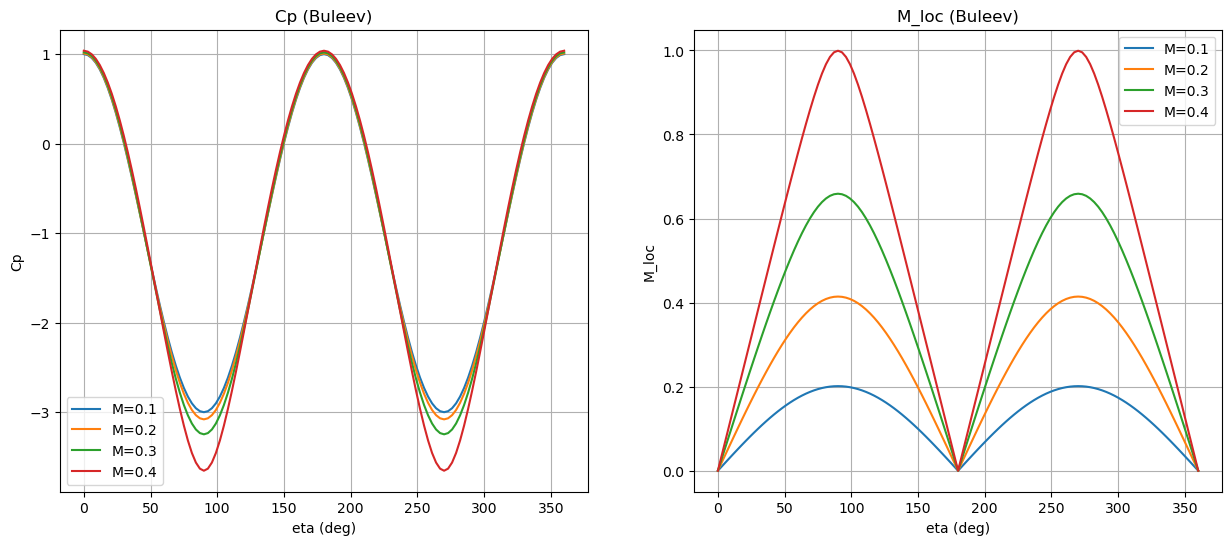

In [6]:
machs = [0.1, 0.2, 0.3, 0.4]
results = {}
phi_current = None

for M in machs:
    phi_current = solve_for_mach_buleev(M, phi_current)
    results[M] = phi_current

table_data = []
idx_90 = np.argmin(np.abs(eta_grid - np.pi/2))

for M in machs:
    phi = results[M]
    phi_eta = np.zeros(N_eta + 1)
    phi_eta[1:N_eta] = (phi[0, 2:N_eta+1] - phi[0, 0:N_eta-1]) / (2 * h_eta)
    phi_eta[0] = 0; phi_eta[N_eta] = 0
    
    q2 = phi_eta**2
    q = np.sqrt(q2)
    
    if M == 0:
        cp = 1 - q2
        m_loc = np.zeros_like(q2)
    else:
        rho = (1 + 0.5 * (gamma - 1) * M**2 * (1 - q2))**(1/(gamma-1))
        cp = 2 / (gamma * M**2) * (rho**gamma - 1)
        a2 = 1 + 0.5 * (gamma - 1) * M**2 * (1 - q2)
        m_loc = q * M / np.sqrt(a2)
    
    table_data.append({
        'M_inf': M, 
        'Cp_pi/2': cp[idx_90], 
        'M_loc_pi/2': m_loc[idx_90]
    })
    
    df_m = pd.DataFrame({
        'eta_deg': eta_grid * 180 / np.pi,
        'Cp': cp,
        'M_loc': m_loc
    })
    df_m.to_csv(f'results_buleev_M_{M}.csv', index=False)

df_results = pd.DataFrame(table_data)
print("\nРезультаты (Buleev) в точке pi/2:")
print(df_results.to_string(index=False))

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
for M in machs:
    df = pd.read_csv(f'results_buleev_M_{M}.csv')
    plt.plot(df['eta_deg'], df['Cp'], label=f'M={M}')
plt.title('Cp (Buleev)')
plt.xlabel('eta (deg)'); plt.ylabel('Cp'); plt.legend(); plt.grid()

plt.subplot(1, 2, 2)
for M in machs:
    df = pd.read_csv(f'results_buleev_M_{M}.csv')
    plt.plot(df['eta_deg'], df['M_loc'], label=f'M={M}')
plt.title('M_loc (Buleev)')
plt.xlabel('eta (deg)'); plt.ylabel('M_loc'); plt.legend(); plt.grid()
plt.show()